# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Mahardika Indra Pratama Ilyasa| 5054251045|

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [39]:
# Import library yang dibutuhkan.
# Import library yang dibutuhkan.
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


from kagglehub import KaggleDatasetAdapter
path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Dataset berhasil diunduh dari: ", path)


files = os.listdir(path)
csv_filename = [f for f in files if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_filename)
df = pd.read_csv(csv_path)

100%|██████████| 16.0k/16.0k [00:00<00:00, 24.3MB/s]

Extracting files...
Dataset berhasil diunduh dari:  /root/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1


In [40]:
# Tampilkan beberapa baris pertama dataset.
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [41]:
# Tampilkan informasi dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [42]:
# Periksa missing value.
print(df.isnull().sum())
print("\nTotal missing value:", df.isnull().sum().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing value: 0


In [43]:
# Tampilkan statistik deskriptif fitur numerik.
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [44]:
# Tampilkan jumlah nilai pada setiap fitur kategorikal.
for col in ['sex', 'smoker', 'region']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- sex ---
sex
male      676
female    662
Name: count, dtype: int64

--- smoker ---
smoker
no     1064
yes     274
Name: count, dtype: int64

--- region ---
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.


In [45]:
#Cek data duplikat

n_dup = df.duplicated().sum()
print("Jumlah baris duplikat:", n_dup)
if n_dup > 0:
    print(df[df.duplicated(keep=False)])
    df = df.drop_duplicates().reset_index(drop=True)
    print("Shape setelah drop duplikat:", df.shape)

Jumlah baris duplikat: 1
     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631
Shape setelah drop duplikat: (1337, 7)


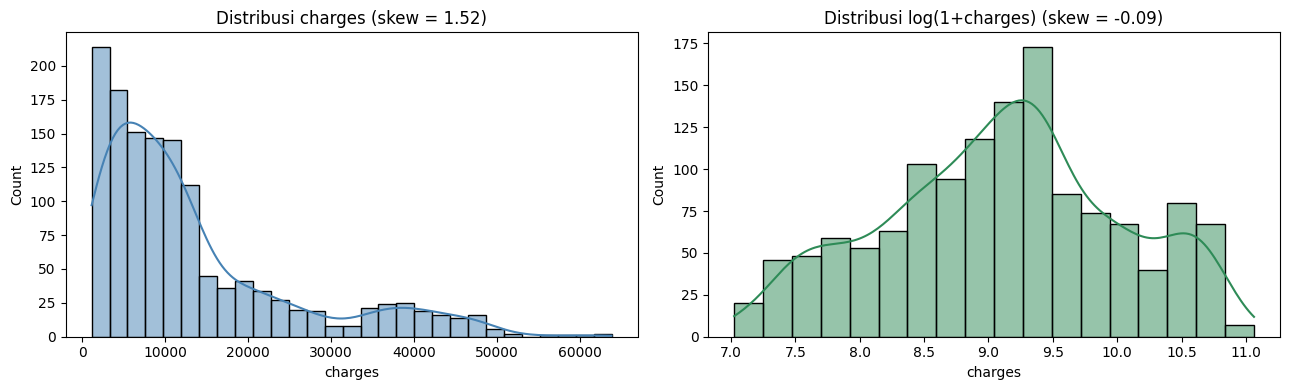

In [46]:
#distribusi target charges dan skewness

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['charges'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f"Distribusi charges (skew = {df['charges'].skew():.2f})")
sns.histplot(np.log1p(df['charges']), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f"Distribusi log(1+charges) (skew = {np.log1p(df['charges']).skew():.2f})")
plt.tight_layout()
plt.show()

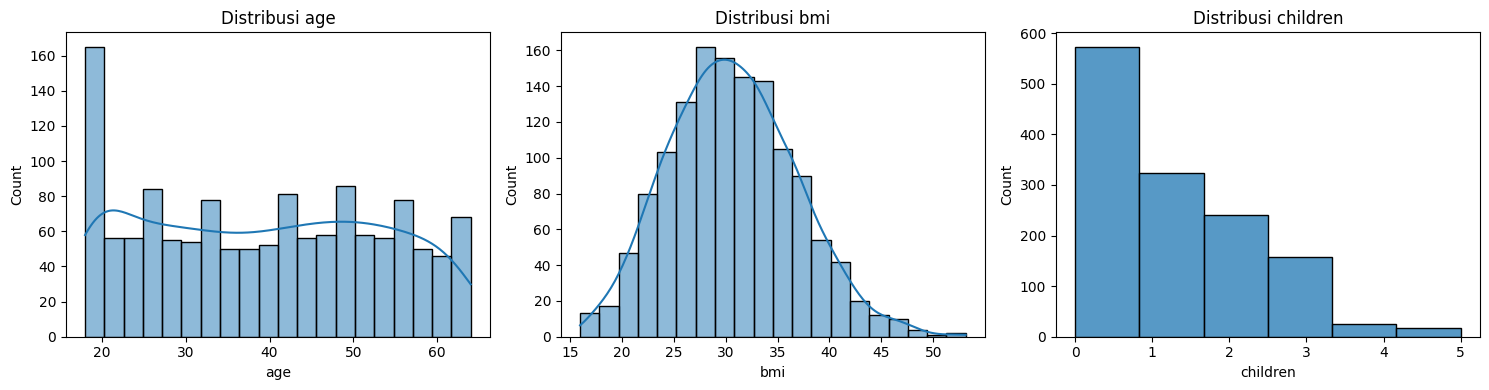

In [47]:
#distribusi fitur numerik

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['age', 'bmi', 'children']):
    sns.histplot(df[col], kde=(col != 'children'), ax=ax, bins=20 if col != 'children' else 6)
    ax.set_title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

Outlier age     : 0 dari 1337 data
Outlier bmi     : 9 dari 1337 data
Outlier charges : 139 dari 1337 data


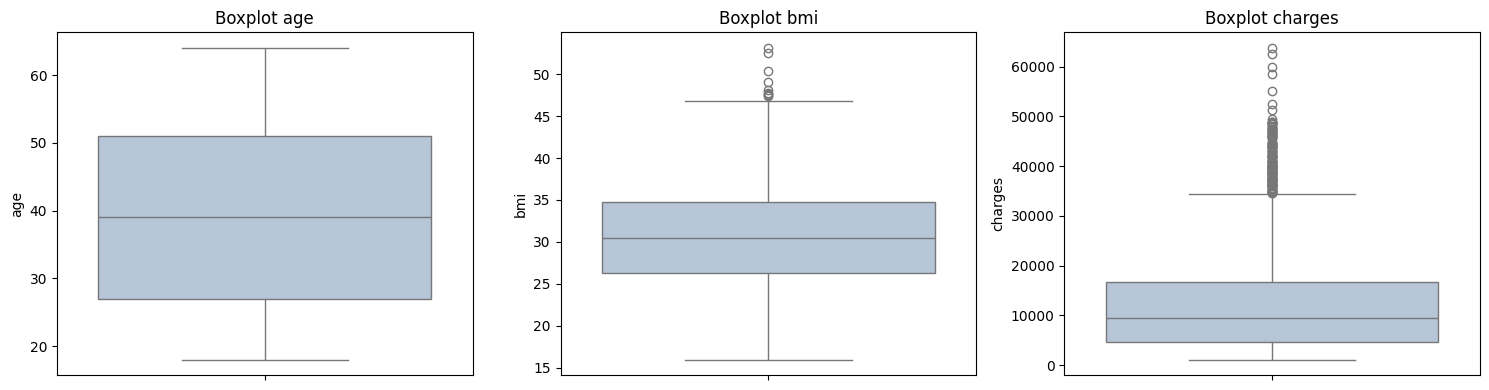

In [48]:
#deteksi outlier dengan metode IQR + boxplot

def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

for col in ['age', 'bmi', 'charges']:
    print(f"Outlier {col:8s}: {iqr_outliers(df[col])} dari {len(df)} data")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['age', 'bmi', 'charges']):
    sns.boxplot(y=df[col], ax=ax, color='lightsteelblue')
    ax.set_title(f"Boxplot {col}")
plt.tight_layout()
plt.show()

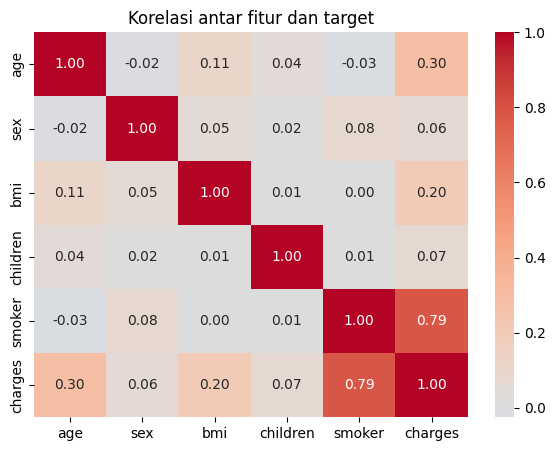

smoker      0.787
age         0.298
bmi         0.198
children    0.067
sex         0.058
Name: charges, dtype: float64


In [49]:
#Heatmap

corr_df = df.copy()
corr_df['smoker'] = (corr_df['smoker'] == 'yes').astype(int)
corr_df['sex'] = (corr_df['sex'] == 'male').astype(int)
corr = corr_df[['age', 'sex', 'bmi', 'children', 'smoker', 'charges']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi antar fitur dan target')
plt.show()
print(corr['charges'].drop('charges').sort_values(ascending=False).round(3))

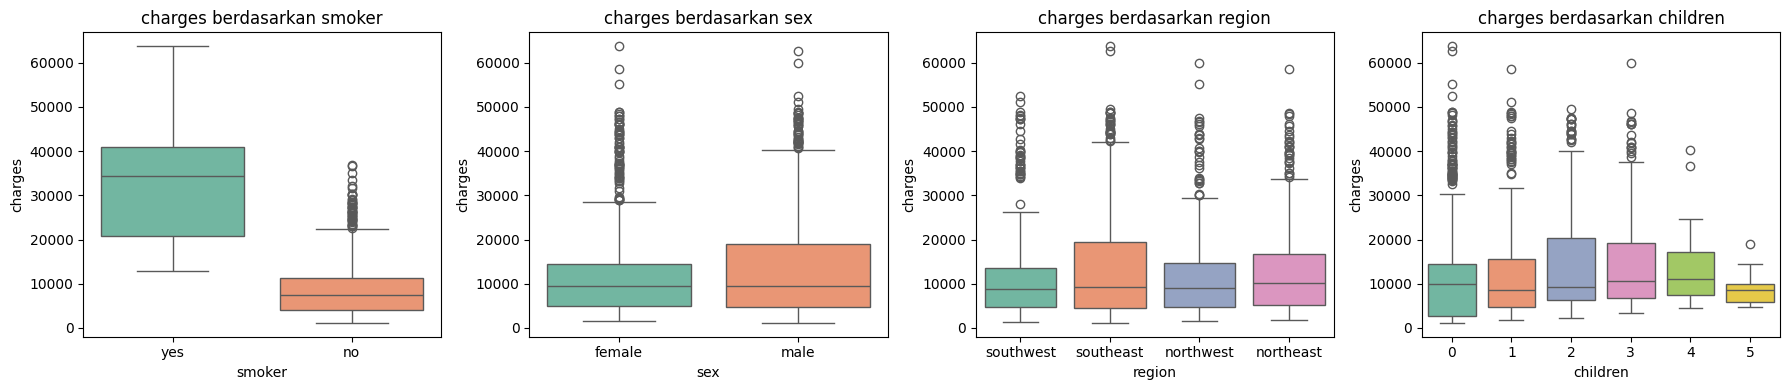

,count,mean,median
smoker,,,
no,1063,8440.66,7345.73
yes,274,32050.23,34456.35


In [74]:
# Membandingkan charges pada tiap fitur kategorikal

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ['smoker', 'sex', 'region', 'children']):
    sns.boxplot(data=df, x=col, y='charges', hue=col, legend=False, ax=ax, palette='Set2')
    ax.set_title(f"charges berdasarkan {col}")
plt.tight_layout()
plt.show();

display(df.groupby('smoker')['charges'].agg(['count', 'mean', 'median']).round(2))

Rata-rata charges:
obese   non-obese  obese (BMI>=30)
smoker                            
no        7977.03          8855.53
yes      21363.22         41557.99


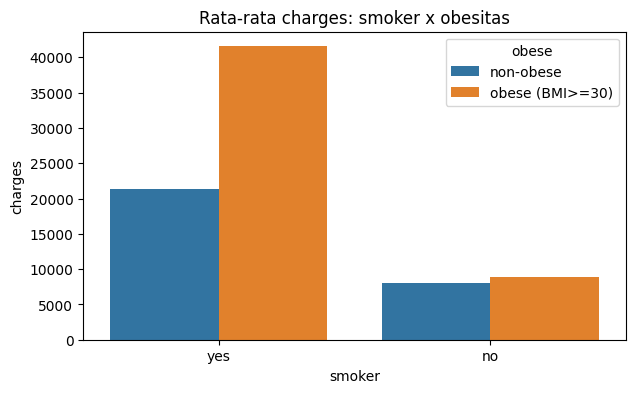

In [52]:
#analisis interaksi antara smoker dan kategori BMI (obesitas)

df_eda = df.copy()
df_eda['obese'] = np.where(df_eda['bmi'] >= 30, 'obese (BMI>=30)', 'non-obese')

pivot = df_eda.pivot_table(index='smoker', columns='obese', values='charges', aggfunc='mean').round(2)
print("Rata-rata charges:")
print(pivot)

plt.figure(figsize=(7, 4))
sns.barplot(data=df_eda, x='smoker', y='charges', hue='obese', errorbar=None)
plt.title('Rata-rata charges: smoker x obesitas')
plt.show()

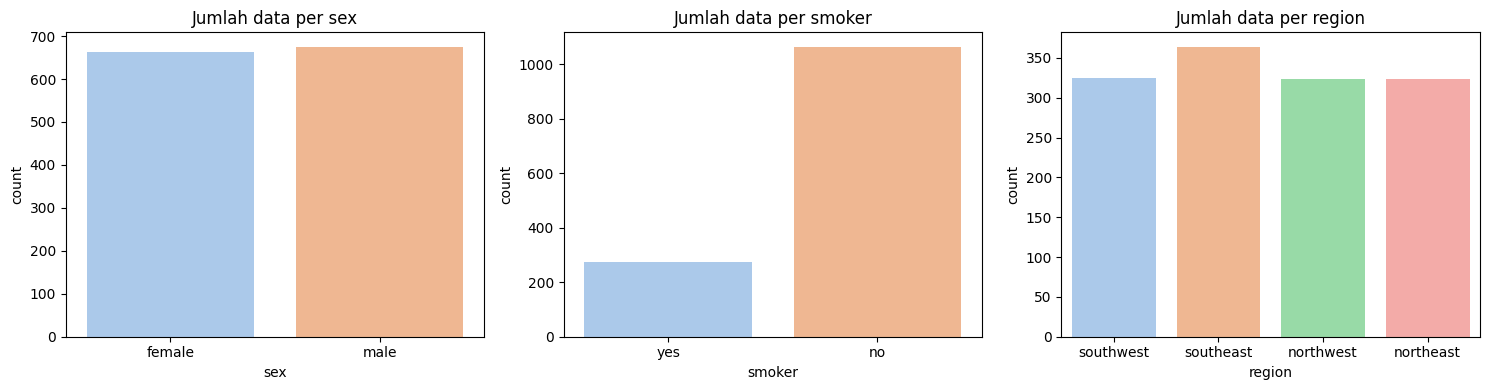

In [53]:
#class balance pada fitur kategorikal

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['sex', 'smoker', 'region']):
    sns.countplot(data=df, x=col, hue=col, legend=False, ax=ax, palette='pastel')
    ax.set_title(f"Jumlah data per {col}")
plt.tight_layout()
plt.show();

### Ringkasan Temuan EDA

1. **Duplikat:** sangat sedikit, dihapus agar tidak terjadi kebocoran data antara train dan test.
2. **Target charges right-skewed** : Distribusi menjadi jauh lebih simetris setelah log, artinya biaya besar jarang tetapi nilainya ekstrem.
3. **Outlier** terutama ada pada charges (dan sedikit pada bmi). Tidak dihapus karena merupakan data nyata yang terkait status perokok.
4. **smoker adalah fitur paling dominan**: korelasi tertinggi dengan charges, dan rata-rata biaya perokok jauh lebih besar dibanding non-perokok. Disusul age, lalu bmi. Fitur sex, children, dan region pengaruhnya kecil.
5. **Hubungan tidak sepenuhnya linear:** scatter age vs charges membentuk beberapa kelompok (pita) dan bmi vs charges memperlihatkan lonjakan biaya pada perokok dengan BMI >= 30. Ini mengindikasikan **efek interaksi** smoker x bmi.
6. **Implikasi modeling:** (a) scaling diperlukan karena skala age, bmi, children berbeda, (b) regularisasi (Ridge/Lasso) kemungkinan tidak banyak membantu karena fitur sedikit dan multikolinearitas rendah, (c) model non-linear diperkirakan lebih unggul.

# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [54]:
# Pisahkan fitur (X) dan target (y).
X = df.drop(columns=['charges'])
y = df['charges']
print("Shape X:", X.shape, "| Shape y:", y.shape)

Shape X: (1337, 6) | Shape y: (1337,)


In [55]:
# Identifikasi kolom numerik dan kategorikal.
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print("Fitur numerik    :", numeric_features)
print("Fitur kategorikal:", categorical_features)

Fitur numerik    : ['age', 'bmi', 'children']
Fitur kategorikal: ['sex', 'smoker', 'region']


In [56]:
# Bagi data menjadi train set dan test set (80:20).
# stratify tidak dipakai karena target kontinu; random_state dikunci agar hasil reproducible.
from sklearn.model_selection import train_test_split, GridSearchCV, KFold

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1069, 6) | Test: (268, 6)


In [57]:
# Buat preprocessing untuk fitur numerik dan kategorikal.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# (a) Dengan scaling -> untuk Linear, Polynomial, Ridge, Lasso, SVR
preprocessor_scaled = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

# (b) Tanpa scaling -> untuk Decision Tree (cukup One-Hot Encoding)
preprocessor_tree = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

# fit HANYA pada train set agar tidak terjadi data leakage
X_train_sc = preprocessor_scaled.fit_transform(X_train)
X_test_sc  = preprocessor_scaled.transform(X_test)

X_train_tree = preprocessor_tree.fit_transform(X_train)
X_test_tree  = preprocessor_tree.transform(X_test)

feature_names = preprocessor_scaled.get_feature_names_out()
print("Fitur setelah preprocessing:", list(feature_names))
print("Shape train (scaled):", X_train_sc.shape)

# Skema cross-validation yang dipakai untuk semua tuning
cv = KFold(n_splits=5, shuffle=True, random_state=42)

Fitur setelah preprocessing: ['num__age', 'num__bmi', 'num__children', 'cat__sex_male', 'cat__smoker_yes', 'cat__region_northwest', 'cat__region_southeast', 'cat__region_southwest']
Shape train (scaled): (1069, 8)


# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [58]:
# Inisialisasi dan latih Linear Regression.
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_sc, y_train)

coef_df = pd.DataFrame({'fitur': feature_names, 'koefisien': lin_reg.coef_}).sort_values('koefisien', key=abs, ascending=False)
print("Intercept:", round(lin_reg.intercept_, 2))
coef_df

Intercept: 8947.95


,fitur,koefisien
4,cat__smoker_yes,23077.764593
0,num__age,3472.975553
1,num__bmi,1927.828251
6,cat__region_southeast,-838.919616
7,cat__region_southwest,-659.139752
2,num__children,636.501185
5,cat__region_northwest,-391.761455
3,cat__sex_male,-101.542054


In [59]:
# Lakukan prediksi pada test set.
y_pred_lin = lin_reg.predict(X_test_sc)
print("Contoh prediksi:", y_pred_lin[:5].round(2))

Contoh prediksi: [ 8143.69  5737.12 14369.31 31745.51  8962.39]


## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [60]:
# Buat fitur polynomial dan latih model.
# Degree dicari lewat eksperimen (GridSearchCV, 5-fold CV pada train set).
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('lr', LinearRegression())
])
poly_grid = GridSearchCV(poly_pipe, {'poly__degree': [1, 2, 3, 4]},
                         cv=cv, scoring='r2', return_train_score=True)
poly_grid.fit(X_train_sc, y_train)

poly_cv = pd.DataFrame(poly_grid.cv_results_)[['param_poly__degree', 'mean_train_score', 'mean_test_score']]
print(poly_cv.rename(columns={'param_poly__degree':'degree','mean_train_score':'R2 train (CV)','mean_test_score':'R2 validasi (CV)'}))
print("\nDegree terbaik:", poly_grid.best_params_['poly__degree'])
poly_reg = poly_grid.best_estimator_

   degree  R2 train (CV)  R2 validasi (CV)
0       1       0.730136          0.722784
1       2       0.835125          0.819726
2       3       0.850996          0.801614
3       4       0.875988          0.661524

Degree terbaik: 2


In [61]:
# Lakukan prediksi pada test set.
y_pred_poly = poly_reg.predict(X_test_sc)
print("Contoh prediksi:", y_pred_poly[:5].round(2))

Contoh prediksi: [ 8353.84  6542.12 14316.74 35908.93  5652.8 ]


## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [62]:
# Inisialisasi dan latih Ridge Regression.
from sklearn.linear_model import Ridge

ridge_grid = GridSearchCV(Ridge(), {'alpha': np.logspace(-3, 3, 13)},
                          cv=cv, scoring='r2')
ridge_grid.fit(X_train_sc, y_train)
print("Alpha terbaik (Ridge):", ridge_grid.best_params_['alpha'])
print("R2 CV terbaik        :", round(ridge_grid.best_score_, 4))
ridge_reg = ridge_grid.best_estimator_

Alpha terbaik (Ridge): 1.0
R2 CV terbaik        : 0.7228


In [63]:
# Lakukan prediksi pada test set.
y_pred_ridge = ridge_reg.predict(X_test_sc)
print("Contoh prediksi:", y_pred_ridge[:5].round(2))

Contoh prediksi: [ 8170.65  5767.79 14379.97 31637.01  9003.53]


## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [64]:
# Inisialisasi dan latih Lasso Regression.
from sklearn.linear_model import Lasso

lasso_grid = GridSearchCV(Lasso(max_iter=20000), {'alpha': np.logspace(-2, 3, 11)},
                          cv=cv, scoring='r2')
lasso_grid.fit(X_train_sc, y_train)
print("Alpha terbaik (Lasso):", lasso_grid.best_params_['alpha'])
print("R2 CV terbaik        :", round(lasso_grid.best_score_, 4))
lasso_reg = lasso_grid.best_estimator_

# Fitur yang dinolkan oleh Lasso (seleksi fitur otomatis)
lasso_coef = pd.Series(lasso_reg.coef_, index=feature_names)
print("\nKoefisien Lasso:")
print(lasso_coef.round(2))
print("Fitur yang dinolkan:", list(lasso_coef[lasso_coef == 0].index))

Alpha terbaik (Lasso): 100.0
R2 CV terbaik        : 0.7232

Koefisien Lasso:
num__age                  3393.38
num__bmi                  1753.06
num__children              552.45
cat__sex_male               -0.00
cat__smoker_yes          22408.07
cat__region_northwest        0.00
cat__region_southeast       -0.00
cat__region_southwest       -0.00
dtype: float64
Fitur yang dinolkan: ['cat__sex_male', 'cat__region_northwest', 'cat__region_southeast', 'cat__region_southwest']


In [65]:
# Lakukan prediksi pada test set.
y_pred_lasso = lasso_reg.predict(X_test_sc)
print("Contoh prediksi:", y_pred_lasso[:5].round(2))

Contoh prediksi: [ 8094.11  5988.23 13986.67 30966.14  9254.67]


## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [66]:
# Inisialisasi dan latih Decision Tree Regressor.
# Data tanpa scaling (pohon tidak sensitif terhadap skala fitur).
from sklearn.tree import DecisionTreeRegressor

tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
     'min_samples_leaf': [1, 5, 10, 20, 30]},
    cv=cv, scoring='r2'
)
tree_grid.fit(X_train_tree, y_train)
print("Parameter terbaik:", tree_grid.best_params_)
print("R2 CV terbaik    :", round(tree_grid.best_score_, 4))
tree_reg = tree_grid.best_estimator_

imp = pd.Series(tree_reg.feature_importances_, index=preprocessor_tree.get_feature_names_out()).sort_values(ascending=False)
print("\nFeature importance:")
print(imp.round(4))

Parameter terbaik: {'max_depth': 4, 'min_samples_leaf': 5}
R2 CV terbaik    : 0.8341

Feature importance:
cat__smoker_yes          0.7007
num__bmi                 0.1722
num__age                 0.1189
num__children            0.0082
cat__sex_male            0.0000
cat__region_northwest    0.0000
cat__region_southeast    0.0000
cat__region_southwest    0.0000
dtype: float64


In [67]:
# Lakukan prediksi pada test set.
y_pred_tree = tree_reg.predict(X_test_tree)
print("Contoh prediksi:", y_pred_tree[:5].round(2))

Contoh prediksi: [11016.04  7357.27 11016.04 40778.86  7357.27]


## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [68]:
# Inisialisasi dan latih SVR.
# Target 'charges' berskala puluhan ribu, jadi C harus besar agar SVR mampu mengikuti target.
from sklearn.svm import SVR

# Pembanding: SVR dengan parameter default (untuk melihat dampak tuning)
svr_default = SVR().fit(X_train_sc, y_train)
from sklearn.metrics import r2_score
print("R2 test SVR default :", round(r2_score(y_test, svr_default.predict(X_test_sc)), 4))

svr_grid = GridSearchCV(
    SVR(kernel='rbf'),
    {'C': [1e3, 1e4, 1e5],
     'gamma': ['scale', 0.01, 0.05, 0.1],
     'epsilon': [10, 100, 1000]},
    cv=cv, scoring='r2', n_jobs=-1
)
svr_grid.fit(X_train_sc, y_train)
print("Parameter terbaik   :", svr_grid.best_params_)
print("R2 CV terbaik       :", round(svr_grid.best_score_, 4))
svr_reg = svr_grid.best_estimator_

R2 test SVR default : -0.1333
Parameter terbaik   : {'C': 100000.0, 'epsilon': 1000, 'gamma': 0.05}
R2 CV terbaik       : 0.8238


In [69]:
# Lakukan prediksi pada test set.
y_pred_svr = svr_reg.predict(X_test_sc)
print("Contoh prediksi:", y_pred_svr[:5].round(2))

Contoh prediksi: [ 9357.41  6415.52 12391.83 33534.64  5339.78]


# 4. Evaluasi Model

In [70]:
# Hitung MAE, MSE, RMSE, dan R² untuk setiap model.
# Sajikan hasil dalam satu tabel perbandingan.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions = {
    'Linear Regression':     (y_pred_lin,   lin_reg.predict(X_train_sc)),
    'Polynomial Regression': (y_pred_poly,  poly_reg.predict(X_train_sc)),
    'Ridge Regression':      (y_pred_ridge, ridge_reg.predict(X_train_sc)),
    'Lasso Regression':      (y_pred_lasso, lasso_reg.predict(X_train_sc)),
    'Decision Tree':         (y_pred_tree,  tree_reg.predict(X_train_tree)),
    'SVR':                   (y_pred_svr,   svr_reg.predict(X_train_sc)),
}

rows = []
for name, (pred_test, pred_train) in predictions.items():
    mse = mean_squared_error(y_test, pred_test)
    rows.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, pred_test),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2 Test': r2_score(y_test, pred_test),
        'R2 Train': r2_score(y_train, pred_train),
    })

results = pd.DataFrame(rows).set_index('Model')
results['Gap (Train-Test)'] = results['R2 Train'] - results['R2 Test']
results = results.sort_values('RMSE')
results.round(4)

,MAE,MSE,RMSE,R2 Test,R2 Train,Gap (Train-Test)
Model,,,,,,
Decision Tree,2621.3124,1.888663e+07,4345.8752,0.8972,0.8552,-0.0420
SVR,2344.6650,2.083032e+07,4564.0250,0.8866,0.8352,-0.0514
Polynomial Regression,2867.3174,2.158584e+07,4646.0568,0.8825,0.8340,-0.0485
Linear Regression,4177.0456,3.547802e+07,5956.3429,0.8069,0.7299,-0.0770
Ridge Regression,4193.8919,3.566313e+07,5971.8617,0.8059,0.7299,-0.0760
Lasso Regression,4256.5831,3.696435e+07,6079.8317,0.7988,0.7286,-0.0703


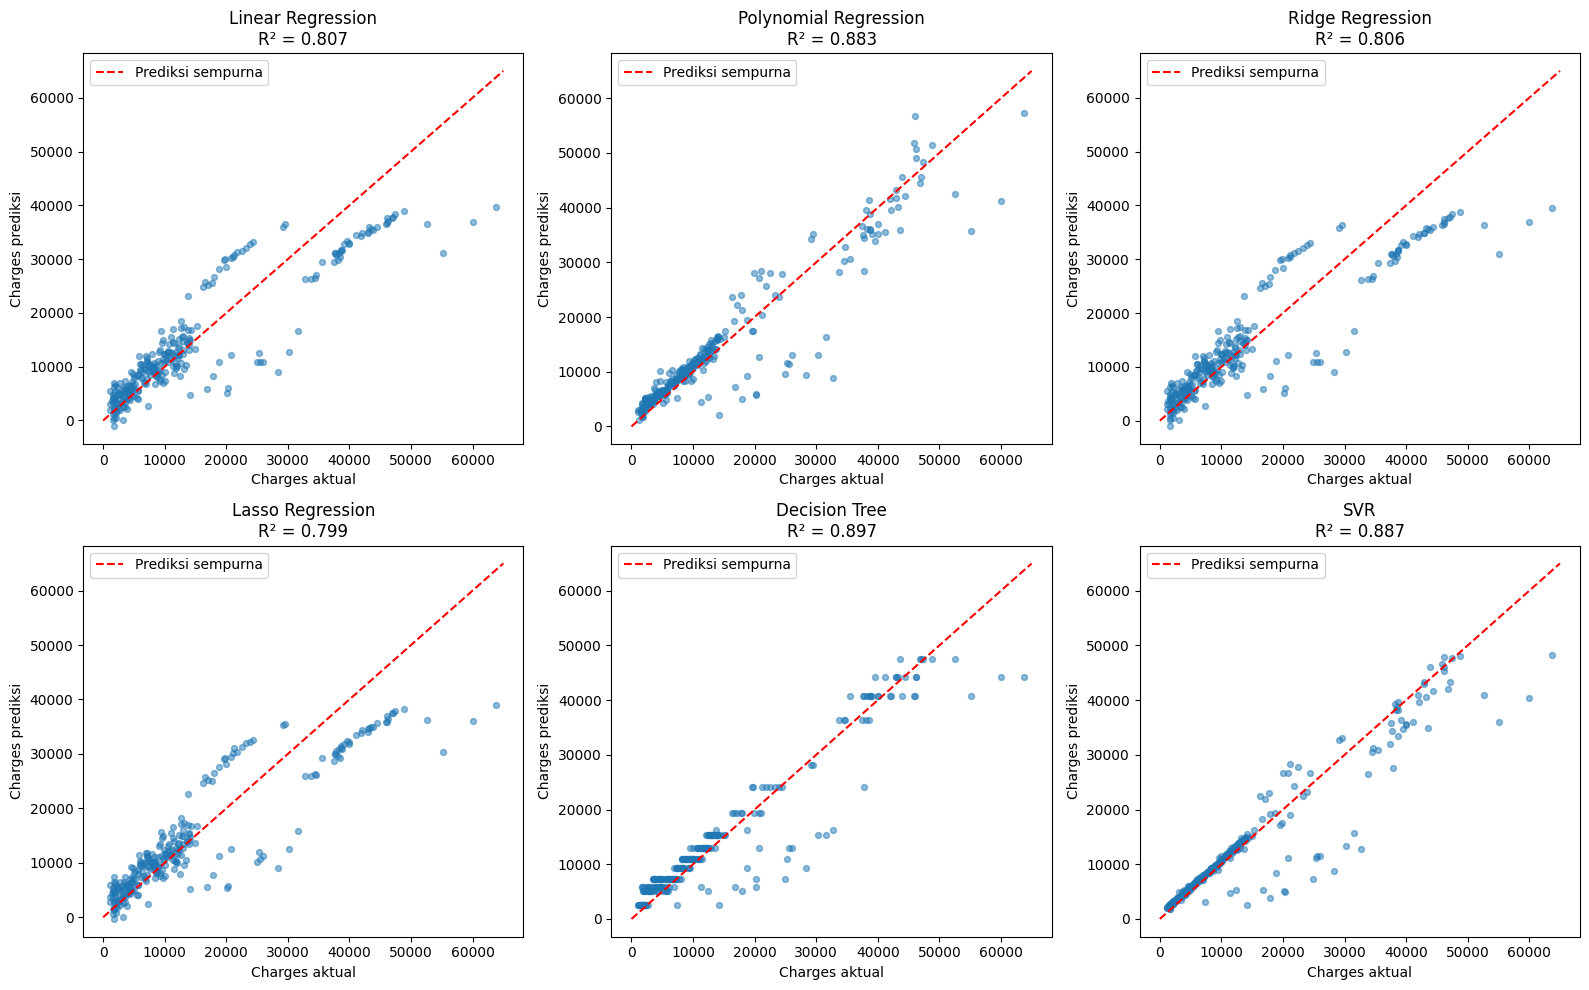

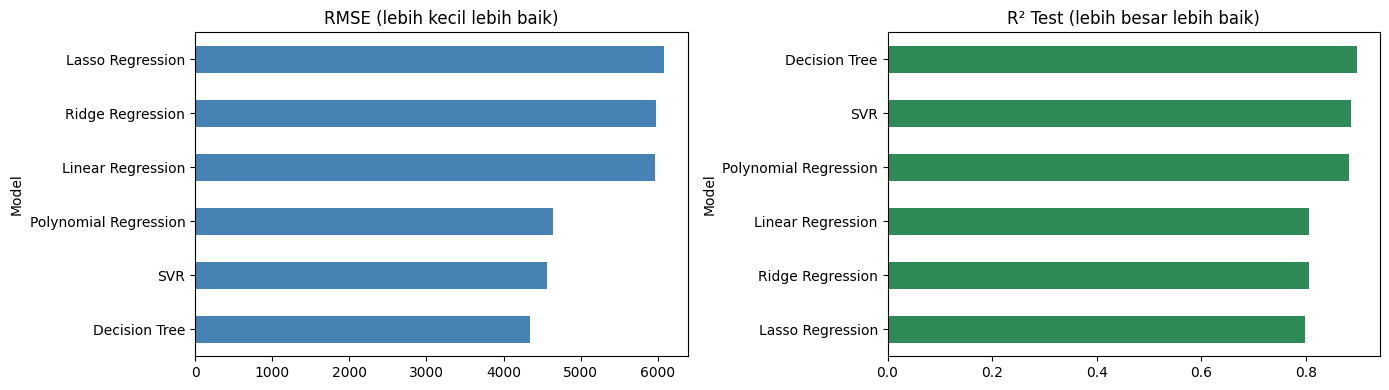

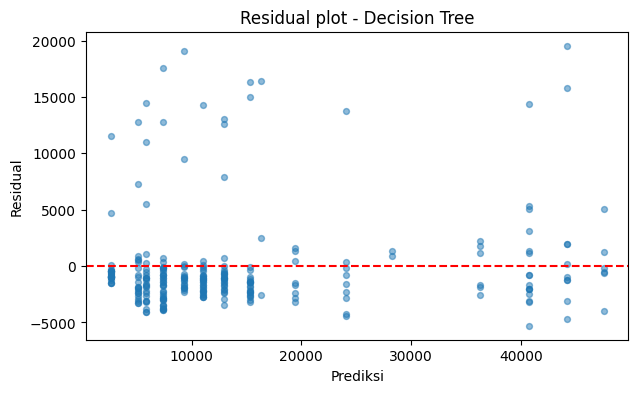


Model terbaik berdasarkan RMSE terendah: Decision Tree


In [71]:
# Buat visualisasi perbandingan nilai aktual dan prediksi jika diperlukan.
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
lims = [0, max(y_test.max(), 65000)]
for ax, (name, (pred_test, _)) in zip(axes.ravel(), predictions.items()):
    ax.scatter(y_test, pred_test, alpha=0.5, s=18)
    ax.plot(lims, lims, 'r--', lw=1.5, label='Prediksi sempurna')
    ax.set_title(f"{name}\nR² = {r2_score(y_test, pred_test):.3f}")
    ax.set_xlabel('Charges aktual')
    ax.set_ylabel('Charges prediksi')
    ax.legend()
plt.tight_layout()
plt.show()

# Perbandingan RMSE dan R2 antar model
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
results['RMSE'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('RMSE (lebih kecil lebih baik)')
results['R2 Test'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('R² Test (lebih besar lebih baik)')
plt.tight_layout()
plt.show()

# Residual plot model terbaik
best_model = results.index[0]
resid = y_test - predictions[best_model][0]
plt.figure(figsize=(7, 4))
plt.scatter(predictions[best_model][0], resid, alpha=0.5, s=18)
plt.axhline(0, color='r', ls='--')
plt.title(f'Residual plot - {best_model}')
plt.xlabel('Prediksi')
plt.ylabel('Residual')
plt.show()

print("\nModel terbaik berdasarkan RMSE terendah:", best_model)

# 5. Analisis

#### Bandingkan hasil Linear Regression, Polynomial Regression, Ridge, Lasso, Decision Tree Regressor, dan SVR berdasarkan metrik evaluasi. Jelaskan pengaruh preprocessing dan parameter yang digunakan terhadap hasil.


In [72]:
# Ringkasan otomatis hasil eksperimen (angka mengikuti output tabel evaluasi di atas)
best = results.index[0]
worst = results.index[-1]
print(f"Model terbaik  (RMSE terendah): {best}  | RMSE = {results.loc[best,'RMSE']:.2f} | R2 = {results.loc[best,'R2 Test']:.4f}")
print(f"Model terburuk (RMSE tertinggi): {worst} | RMSE = {results.loc[worst,'RMSE']:.2f} | R2 = {results.loc[worst,'R2 Test']:.4f}")
print()
print("Parameter hasil tuning:")
print(f"  Polynomial degree      : {poly_grid.best_params_['poly__degree']}")
print(f"  Ridge alpha            : {ridge_grid.best_params_['alpha']}")
print(f"  Lasso alpha            : {lasso_grid.best_params_['alpha']}")
print(f"  Decision Tree          : {tree_grid.best_params_}")
print(f"  SVR                    : {svr_grid.best_params_}")
print()
print("Model dengan gap train-test terbesar (indikasi overfitting):", results['Gap (Train-Test)'].idxmax())

Model terbaik  (RMSE terendah): Decision Tree  | RMSE = 4345.88 | R2 = 0.8972
Model terburuk (RMSE tertinggi): Lasso Regression | RMSE = 6079.83 | R2 = 0.7988

Parameter hasil tuning:
  Polynomial degree      : 2
  Ridge alpha            : 1.0
  Lasso alpha            : 100.0
  Decision Tree          : {'max_depth': 4, 'min_samples_leaf': 5}
  SVR                    : {'C': 100000.0, 'epsilon': 1000, 'gamma': 0.05}

Model dengan gap train-test terbesar (indikasi overfitting): Decision Tree


### Pembahasan

> Catatan: angka pasti ada pada tabel evaluasi dan ringkasan otomatis di atas. Pembahasan berikut menjelaskan pola yang umumnya muncul pada dataset ini; sesuaikan kalimat dengan angka hasil run kalian.

**1. Perbandingan antar model**
- **Linear Regression** menjadi baseline. Hasilnya terbatas karena hubungan `charges` dengan fitur tidak murni linear (ada efek interaksi `smoker x bmi` dan kurva pada `age`).
- **Polynomial Regression** umumnya memperbaiki baseline secara jelas karena fitur polynomial (terutama suku interaksi) menangkap hubungan non-linear. Degree dipilih lewat CV; degree yang terlalu tinggi membuat gap train-test melebar (overfitting).
- **Ridge dan Lasso** hasilnya hampir sama dengan Linear Regression. Alasannya, jumlah fitur sedikit, multikolinearitas rendah, dan model dasarnya sudah tidak overfit, sehingga regularisasi tidak punya banyak hal untuk diperbaiki. Lasso hanya berpotensi menolkan fitur berpengaruh kecil seperti `region` atau `sex`. Keduanya tetap linear, sehingga masalah utama (non-linearitas) tidak teratasi.
- **Decision Tree** dapat menangkap interaksi dan non-linearitas secara otomatis tanpa scaling. Hasil sangat bergantung pada `max_depth` dan `min_samples_leaf`: pohon terlalu dalam menghafal data train (overfit), pohon terlalu dangkal underfit. Feature importance biasanya didominasi `smoker`, `bmi`, dan `age`.
- **SVR (kernel RBF)** juga mampu memodelkan non-linearitas. Dengan parameter default hasilnya buruk (R² sangat rendah, bahkan bisa negatif) karena `C` default terlalu kecil untuk target berskala puluhan ribu; setelah tuning `C`, `gamma`, dan `epsilon`, performanya naik drastis dan kompetitif.

**2. Pengaruh preprocessing**
- **StandardScaler** penting untuk SVR (berbasis jarak kernel) dan membantu Ridge/Lasso (penalti dikenakan adil ke semua koefisien). Untuk Linear Regression biasa, scaling tidak mengubah prediksi tetapi membuat koefisien dapat dibandingkan. Decision Tree tidak terpengaruh scaling.
- **OneHotEncoder (drop='first')** mengubah kategori menjadi numerik tanpa memberi urutan palsu, dan menghindari dummy variable trap (multikolinearitas sempurna).
- **Fit pada train set saja** mencegah data leakage sehingga skor test lebih jujur.

**3. Pengaruh parameter**
- `degree` (Polynomial): menaikkan kapasitas model, tetapi terlalu tinggi menyebabkan overfitting.
- `alpha` (Ridge/Lasso): makin besar, koefisien makin ditekan; nilai optimal pada data ini cenderung kecil.
- `max_depth` dan `min_samples_leaf` (Tree): mengontrol kompleksitas pohon.
- `C`, `gamma`, `epsilon` (SVR): `C` besar membuat model mengikuti data lebih ketat, `gamma` mengatur jangkauan pengaruh satu titik, `epsilon` mengatur lebar tabung toleransi error.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan berdasarkan hasil eksperimen. Saran dapat berupa perubahan parameter, preprocessing, atau eksperimen lanjutan.


**Kesimpulan**
1. Fitur paling berpengaruh terhadap biaya medis adalah `smoker`, diikuti `age` dan `bmi`; `sex`, `children`, dan `region` berpengaruh kecil.
2. Model non-linear (Polynomial, Decision Tree, SVR yang sudah di-tuning) umumnya mengungguli model linear (Linear, Ridge, Lasso), karena data memiliki efek interaksi dan pola non-linear.
3. Ridge dan Lasso tidak memberikan peningkatan berarti dibanding Linear Regression karena data memiliki sedikit fitur dan sedikit multikolinearitas.
4. Preprocessing (scaling dan one-hot encoding) serta tuning hyperparameter dengan cross-validation sangat memengaruhi hasil, terutama untuk SVR.
5. Model terbaik adalah model dengan RMSE terendah dan R² tertinggi pada tabel evaluasi, dengan memperhatikan gap train-test agar tidak overfit.

**Saran**
- Tambahkan fitur rekayasa (feature engineering), misalnya `smoker x bmi`, `bmi >= 30` (obesitas), atau `age^2`, agar model linear dapat menangkap interaksi.
- Coba transformasi target (`log(charges)`) untuk mengurangi skewness, lalu kembalikan prediksi dengan `expm1`.
- Coba model ensemble seperti Random Forest, Gradient Boosting, atau XGBoost.
- Gunakan `RandomizedSearchCV` atau rentang parameter yang lebih luas, serta laporkan hasil dengan repeated cross-validation agar tidak bergantung pada satu split.
- Evaluasi dengan metrik yang lebih robust terhadap outlier seperti MAPE atau Median Absolute Error.